In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
# from utils.read_group_danmu import read_group_danmu

### Load data

In [2]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
# del scores_dict['BV1zW411d7Rb']
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample.pkl', 'rb') as f:
    time_dict= pickle.load(f)
# del time_dict['BV1zW411d7Rb']

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

102
102


In [3]:
scores_all = np.zeros((0,6))
n_samples = []

scores_key = list(scores_dict.keys())
count = 0
for key in scores_key:
    print(scores_dict[key].shape)
    scores_all = np.concatenate((scores_all, scores_dict[key]), 0)
    n_samples.append(scores_dict[key].shape[0])
    count += 1
print(scores_all.shape)
n_samples_cum = np.concatenate((np.array([0]), np.cumsum(n_samples)))
print(n_samples_cum[-5:])

(4565, 6)
(3699, 6)
(4218, 6)
(1158, 6)
(3955, 6)
(3907, 6)
(4714, 6)
(3192, 6)
(2984, 6)
(3800, 6)
(3051, 6)
(3007, 6)
(4277, 6)
(5197, 6)
(3371, 6)
(3058, 6)
(3692, 6)
(3824, 6)
(3642, 6)
(3513, 6)
(6846, 6)
(2616, 6)
(2717, 6)
(3223, 6)
(3500, 6)
(4148, 6)
(3174, 6)
(3960, 6)
(3516, 6)
(3088, 6)
(4303, 6)
(2692, 6)
(4010, 6)
(2179, 6)
(2700, 6)
(4200, 6)
(3530, 6)
(3611, 6)
(3210, 6)
(4031, 6)
(3293, 6)
(4606, 6)
(5233, 6)
(3487, 6)
(4200, 6)
(3405, 6)
(4484, 6)
(3562, 6)
(3987, 6)
(4766, 6)
(3337, 6)
(2703, 6)
(2995, 6)
(2522, 6)
(4044, 6)
(3547, 6)
(3019, 6)
(2789, 6)
(1396, 6)
(3753, 6)
(3557, 6)
(4445, 6)
(5073, 6)
(3361, 6)
(3299, 6)
(3914, 6)
(2651, 6)
(2634, 6)
(3734, 6)
(3296, 6)
(5312, 6)
(4252, 6)
(2729, 6)
(2721, 6)
(3117, 6)
(2910, 6)
(4223, 6)
(2703, 6)
(3214, 6)
(3854, 6)
(3990, 6)
(3631, 6)
(3372, 6)
(2874, 6)
(3032, 6)
(2207, 6)
(3129, 6)
(2081, 6)
(2788, 6)
(2601, 6)
(4910, 6)
(3071, 6)
(1895, 6)
(4002, 6)
(4031, 6)
(3191, 6)
(2957, 6)
(3355, 6)
(2830, 6)
(3452, 6)


### PCA

Explained variance ratio: [0.49378133 0.19681466 0.16693501 0.08574263 0.03698317 0.01974321]


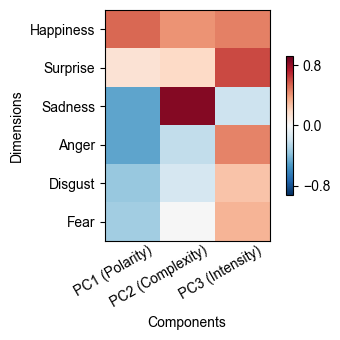

In [4]:
from sklearn.decomposition import PCA
import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(preds_all)

pca = PCA(n_components=6)

X_pca = pca.fit_transform(scores_all)

print("Explained variance ratio:", pca.explained_variance_ratio_)

pca.components_[[3,4],:] = -pca.components_[[3,4],:]

matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca.components_.transpose()[:,:3],cmap='RdBu_r')
ax.set_aspect(0.7)
plt.xticks(np.arange(0.4,3.4,1),['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)'], rotation=30, ha='right')
plt.gca().tick_params(axis='x', pad=2)
plt.tick_params(axis='x', length=0)
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
# max_lim = np.maximum(np.nanmax(pca.components_), -np.nanmin(pca.components_))
cax.set_clim([-0.921, 0.921])
# print(max_lim)
plt.tight_layout()
plt.savefig('figures/pca_scores_danmu_all_PC3.svg', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
from copy import deepcopy
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    preds = pickle.load(f)

In [6]:
from copy import deepcopy
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    preds = pickle.load(f)
preds = preds['forrest_gump']
# preds = np.load('scores_longMovie_deepseek.npy')

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
print(danmu_dict.keys())
time_ranges = danmu_dict['forrest_gump.csv_time_range']

# cut predicted scores and time_points_german into 8 runs
cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]
time_points = np.zeros(len(time_ranges))
for i in range(len(time_points)):
    time_points[i] = np.mean(time_ranges[i])
# Find time points in the original movie (time points are for bilibili version, which cut 4 segments)

time_points_ori = deepcopy(time_points)
time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

# Find time points in the german version. (the frame rate was different from the original movie)
time_points_german = time_points_ori / (25/(24000/1001))

preds_cut = np.zeros((0,6))
time_points_german_cut = np.zeros(0)
for i in range(len(cut_index2)):
    preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
    time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

# Get time of ratings in German version
time_ratings = []
seg_lens = [902,882,876,976,924,878,1084,676]
for i in range(8):
    tmp = np.arange(0,seg_lens[i],2)
    if (i > 0) and (i < 7): # The first and the last runs only have one segment
        tmp = tmp + cut_index2[i*2-1][0]
        tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
    elif i == 7:
        tmp = tmp + cut_index2[i*2-1][0]
    time_ratings.extend(tmp)
    
# Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
preds_cut_resample = np.zeros((3599, 6))
for i in range(3599):
    if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
        preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
    else:
        preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

# Smooth the predicted scores over ts windows
smooth_win = 10
preds_smoothed = np.zeros(preds_cut_resample.shape)
for i in range(preds_cut_resample.shape[0]):
    tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
    preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)

dict_keys(['forrest_gump.csv', 'forrest_gump.csv_time_range'])


In [7]:
from scipy import stats
import h5py
# load ratings
path=r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\Lettieri-Forrest\forrest_gump_movie_italian\raw_ratings.mat'
ratings_all=np.zeros([12,6,3599])
count = 0
with h5py.File(path,'r') as file:
    for item in file.items():
        # print(item[0])
        tmp = file[item[0]][:][[0,1,3,4,5,2],:] # reorder to [高兴、惊讶、悲伤、愤怒、厌恶、恐惧]
        ratings_all[count]=tmp
        count += 1
ratings_mean = np.mean(ratings_all, axis=0)
ratings_mean = ratings_mean.transpose()

ratings_smoothed = np.zeros(preds_cut_resample.shape)
for i in range(ratings_smoothed.shape[0]):
    tmp = ratings_mean[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
    ratings_smoothed[i,:] = np.mean(tmp, axis=0)

Explained variance ratio: [0.54792509 0.22046489 0.1281383  0.06499654 0.02649904 0.01197614]


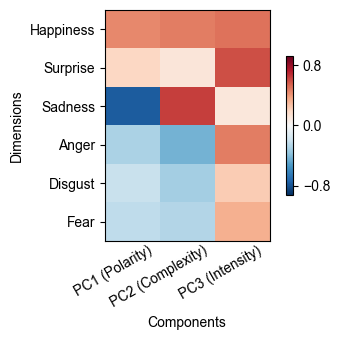

Explained variance ratio: [0.45866067 0.23605802 0.1594916  0.0765148  0.05582819 0.01344671]


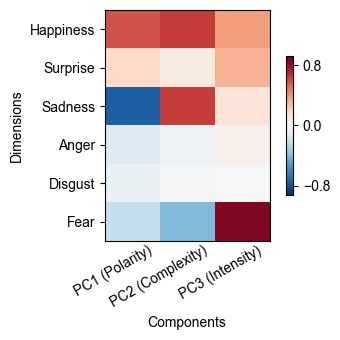

In [8]:
from sklearn.decomposition import PCA
import matplotlib
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(preds_all)

# 创建PCA对象，设定要保留的主成分数量（例如：2个主成分）
pca = PCA(n_components=6)

# 使用PCA降维
X_pca = pca.fit_transform(preds_smoothed)

# 解释方差比例（每个主成分解释的方差占总方差的比例）
print("Explained variance ratio:", pca.explained_variance_ratio_)

pca.components_[[0,3,4],:] = -pca.components_[[0,3,4],:]

matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca.components_.transpose()[:,:3],cmap='RdBu_r')
ax.set_aspect(0.7)
plt.xticks(np.arange(0.4,3.4,1),['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)'], rotation=30, ha='right')
plt.gca().tick_params(axis='x', pad=2)
plt.tick_params(axis='x', length=0)
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
# max_lim = np.maximum(np.nanmax(pca.components_), -np.nanmin(pca.components_))
cax.set_clim([-0.921, 0.921])
# print(max_lim)
plt.tight_layout()
plt.savefig('figures/pca_scores_danmu_forrest_gump_PC3.svg', dpi=300, bbox_inches='tight')
plt.show()


pca = PCA(n_components=6)

# 使用PCA降维
X_pca = pca.fit_transform(ratings_smoothed)

# 解释方差比例（每个主成分解释的方差占总方差的比例）
print("Explained variance ratio:", pca.explained_variance_ratio_)

pca.components_[[0,3,4],:] = -pca.components_[[0,3,4],:]

matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(4,3.5))
cax = ax.imshow(pca.components_.transpose()[:,:3],cmap='RdBu_r')
ax.set_aspect(0.7)
plt.xticks(np.arange(0.4,3.4,1),['PC1 (Polarity)', 'PC2 (Complexity)', 'PC3 (Intensity)'], rotation=30, ha='right')
plt.gca().tick_params(axis='x', pad=2)
plt.tick_params(axis='x', length=0)
plt.yticks(np.arange(6), emos)
plt.xlabel('Components')
plt.ylabel('Dimensions')
cbar = plt.colorbar(cax, shrink=0.6)
cbar.set_ticks([-0.8, 0.0, 0.8])
# max_lim = np.maximum(np.nanmax(pca.components_), -np.nanmin(pca.components_))
cax.set_clim([-0.921, 0.921])
# print(max_lim)
plt.tight_layout()
plt.savefig('figures/pca_scores_ratings_forrest_gump_PC3.svg', dpi=300, bbox_inches='tight')
plt.show()

### Emotion dynamic space

In [9]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

def _scott_bandwidth(X2):
    X2 = np.asarray(X2, float); n, d = X2.shape
    s = X2.std(axis=0, ddof=1).mean()
    return s * n ** (-1.0 / (d + 4))

def _hdr_thresholds(dens_grid, levels=(0.5, 0.8, 0.95), cell_area=1.0):
    f = dens_grid.ravel()
    idx = np.argsort(f)[::-1]
    mass = np.cumsum(f[idx]) * cell_area
    total = mass[-1]
    thr = []
    for a in levels:
        k = np.searchsorted(mass, a*total)
        k = min(max(k, 0), len(f)-1)
        thr.append(float(f[idx[k]]))
    return sorted(thr)

def _kde_on_grid(X2, xs, ys, bandwidth):
    XX, YY = np.meshgrid(xs, ys)
    grid = np.c_[XX.ravel(), YY.ravel()]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(X2)
    logd = kde.score_samples(grid)
    dens = np.exp(logd).reshape(XX.shape)
    return XX, YY, dens

def _global_assign_and_transition(scores_all, centers6, n_samples_cum, eps=1e-6):
    X = np.asarray(scores_all, float)
    dif = X[:, None, :] - centers6[None, :, :]
    d2 = np.sum(dif*dif, axis=2)
    labels = d2.argmin(axis=1).astype(int)  # 0..5

    K = 6
    C = np.zeros((K, K), float)
    M = len(n_samples_cum) - 1
    for m in range(M):
        s, e = int(n_samples_cum[m]), int(n_samples_cum[m+1])
        if e - s <= 1: continue
        seg = labels[s:e]
        for a, b in zip(seg[:-1], seg[1:]):
            C[a, b] += 1.0
    P = C + eps
    P = P / P.sum(axis=1, keepdims=True)
    pi = (P.sum(axis=0) + eps)
    pi = pi / pi.sum()
    return labels, P, pi

def fit_six_emotion_anchors(
    scores_all, topk_frac=0.20, eps=1e-6
):

    X = np.asarray(scores_all, float)
    N, D = X.shape
    assert D == 6

    sums = X.sum(axis=1, keepdims=True) + eps
    purity = X / sums  
    centers = np.zeros((6, D), float)
    covs = np.zeros((6, D, D), float)
    counts = np.zeros(6, int)

    for k in range(6):
        mask = (X.argmax(axis=1) == k)
        Xk = X[mask]
        # if len(Xk) < min_n:
        #     idx = np.argsort(purity[:, k])[::-1]
        #     take = max(min_n, int(topk_frac * N))
        #     Xk = X[idx[:take]]

        m = len(Xk)
        # print(int(topk_frac * m))
        kk = int(topk_frac * m)
        idx2 = np.argsort(Xk[:, k])[::-1][:kk]
        Xk2 = Xk[idx2]

        centers[k] = Xk2.mean(axis=0)
        C = np.cov(Xk2, rowvar=False)
        C = 0.5*(C + C.T) + 1e-9*np.eye(D)
        covs[k] = C
        counts[k] = len(Xk2)
    return centers, covs, counts

EMO_NAMES  = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
EMO_COLORS = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

In [10]:
centers6, covs6, counts = fit_six_emotion_anchors(
    scores_all,        # (N, 6)
    # purity_tau=1.0,   
    topk_frac=0.50 
    # min_n=500         
)
print("anchors per emotion:", counts)

anchors per emotion: [112913  37849  12221  13095    787   1218]


In [11]:
random_state = 0
grid_res=400
bandwidth=None
bandwidth_scale=1.0
glow_sigma=6.0
levels=(0.5, 0.8, 0.95, 0.99)
    
rng = np.random.default_rng(random_state)

# 1) PCA(2) on pooled data
pca = PCA(n_components=2, svd_solver="full", random_state=random_state)
X2 = pca.fit_transform(scores_all)
C2 = pca.transform(centers6)  

# 3) KDE on a shared grid
pad = 0.01
xmin, xmax = X2[:,0].min(), X2[:,0].max()
ymin, ymax = X2[:,1].min(), X2[:,1].max()
dx, dy = xmax - xmin, ymax - ymin
xmin -= pad*dx; xmax = xmax+pad*dx+0.06; ymin -= pad*dy; ymax += pad*dy

xs = np.linspace(xmin, xmax, grid_res)
ys = np.linspace(ymin, ymax, grid_res)
cell_area = (xs[1]-xs[0]) * (ys[1]-ys[0])

if bandwidth is None:
    bandwidth = _scott_bandwidth(X2) * float(bandwidth_scale)

XX, YY, dens = _kde_on_grid(X2, xs, ys, bandwidth)
dens_blur = gaussian_filter(dens, sigma=glow_sigma)
thr = _hdr_thresholds(dens, levels=levels, cell_area=cell_area)


In [12]:
# with open('kde_prep2.pkl', 'rb') as f:
#     kde_prep = pickle.load(f)
# XX, YY, dens, dens_blur, thr = kde_prep['XX'], kde_prep['YY'], kde_prep['dens'], kde_prep['dens_blur'], kde_prep['thr']

In [13]:
print(xmin, xmax, ymin, ymax)
print(np.min(XX), np.max(XX), np.min(YY), np.max(YY))
xmin, xmax, ymin, ymax = np.min(XX), np.max(XX), np.min(YY), np.max(YY)

-9.375047871028144 4.643644358322811 -5.303414152688677 6.301404531999867
-9.375047871028144 4.643644358322811 -5.303414152688677 6.301404531999867


In [14]:
traj_lines = []
for i in range(102):
    seg = X2[n_samples_cum[i]: n_samples_cum[i+1]]
    traj_lines.append(seg)

In [15]:
levels=(0.5, 0.8, 0.95, 0.999)
thr = _hdr_thresholds(dens, levels=levels, cell_area=cell_area)

In [16]:
from matplotlib.colors import LinearSegmentedColormap
EMO_COLORS = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
EMO_COLORS_WHITE_BG = EMO_COLORS

[Peak cell] iy=162, ix=283, coord=(0.5680, -0.5917)


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\4203426774.py:42: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cs.collections:


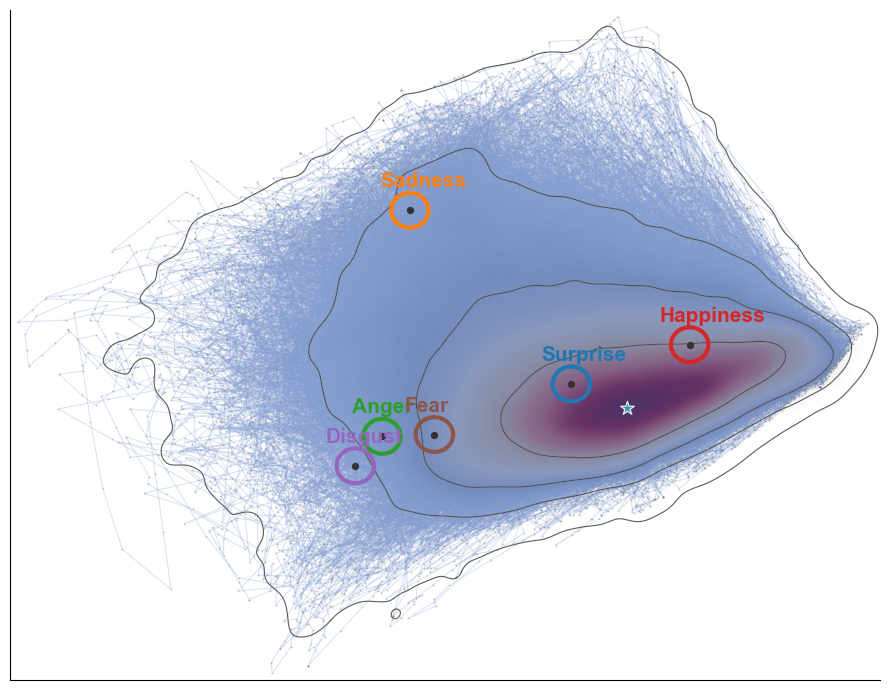

In [17]:
out_path_jpg='figures/emotion_dynamic_space2_noword.svg'
traj_alpha=0.3

fig = plt.figure(figsize=(9, 7), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

D = np.log1p(dens)          # log

vmin = np.min(D)
vmax = np.max(D)

# 使用OrRd色系，从白色开始
colors = ['white', "#CCCBC9", '#FEE8C8', '#FDD49E', '#FDBB84', '#FC8D59', '#EF6548', '#D7301F', '#B30000', '#7F0000']
cmap = LinearSegmentedColormap.from_list('white_OrRd', colors)

# 或者更简单的版本，只使用几个关键颜色
# colors = ['white', '#FEE8C8', '#FDBB84', '#FC8D59', '#EF6548', '#D7301F', '#B30000']
# cmap = LinearSegmentedColormap.from_list('white_OrRd_simple', colors)

idx = np.arange(len(X2))
ax.scatter(X2[idx,0], X2[idx,1],
           s=2.5, c="#333333", alpha=0.2,
           linewidths=0, zorder=0, rasterized=True)

ax.scatter(X2[idx,0], X2[idx,1],
           s=1, c="#1A1A1A", alpha=0.4,
           linewidths=0, zorder=1, rasterized=True)

for seg in traj_lines:
    ax.plot(seg[:,0], seg[:,1], lw=0.8, alpha=traj_alpha, color="#2E5CB8")
    
im = ax.imshow(
    D, extent=(xmin, xmax, ymin, ymax), origin="lower",
    cmap=cmap, vmin=vmin, vmax=vmax,
    alpha=0.45, interpolation="bilinear", aspect="auto", zorder=2
)

# 改为深色等高线
for t in thr:
    cs = ax.contour(XX, YY, dens, levels=[t], colors="#333333", linewidths=0.8, alpha=0.8)
    for c in cs.collections:
        c.set_path_effects([pe.Stroke(linewidth=0.6, foreground="#FFFFFF88"), pe.Normal()])

center_mass = X2.mean(axis=0)
# 定义在白色背景下可见的情绪颜色
# EMO_COLORS_WHITE_BG = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#FFFF33']

for k, (cx, cy) in enumerate(C2):
    ring = Circle((cx, cy), radius=0.22*max(dx,dy)/10,
                    facecolor='none', edgecolor=EMO_COLORS_WHITE_BG[k], linewidth=3.0, zorder=3)
    ax.add_patch(ring)
    ax.scatter([cx], [cy], s=18, color="#333333", zorder=4)
    #v = np.array([cx, cy]) - center_mass
    #v = v / (np.linalg.norm(v) + 1e-9)
    lx, ly = cx-0.035*dx, cy + 0.035*dy#*v[1]
    txt = ax.text(lx, ly, EMO_NAMES[k],
                    color=EMO_COLORS_WHITE_BG[k], fontsize=15, weight="bold", zorder=5)
    # txt.set_path_effects([pe.Stroke(linewidth=1.1, foreground="#FFFFFFCC"), pe.Normal()])

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xticks([]); ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 寻找 dens 的全局最大栅格索引（注意：dens.shape = (ny, nx)）
iy, ix = np.unravel_index(np.argmax(dens), dens.shape)   # 行(y)、列(x)索引
x_peak, y_peak = XX[iy, ix], YY[iy, ix]                  # 映射到坐标系
print(f"[Peak cell] iy={iy}, ix={ix}, coord=({x_peak:.4f}, {y_peak:.4f})")

# 在图上标注峰值（小圆环+星标）
peak_color = '#3B9AB2'  # 亮青蓝色，与红橙色系形成强对比

ax.scatter([x_peak], [y_peak],
           s=108, marker='*',
           color=peak_color,
           edgecolor='#FFFFFFDD', linewidth=0.9, zorder=6)
# ax.scatter([x_peak], [y_peak], s=58, marker='*', color='white',
#            edgecolor='#000000AA', linewidth=1.5, zorder=6)

# cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, shrink=0.3)
# cbar.set_label("Density", color="black")
# cbar.ax.yaxis.set_tick_params(color="black")
# plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')
# ax.set_aspect('equal')
plt.tight_layout()
# plt.savefig(out_path_jpg, dpi=300, bbox_inches='tight')

[Peak cell] iy=162, ix=283, coord=(0.5680, -0.5917)
[Peak density] 0.122742
PC1 profile maximum: 1.0 at x = 0.5680345873836856
PC2 profile maximum: 1.0 at y = -0.5916832581534788


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\1199168369.py:348: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  collections = cs.collections


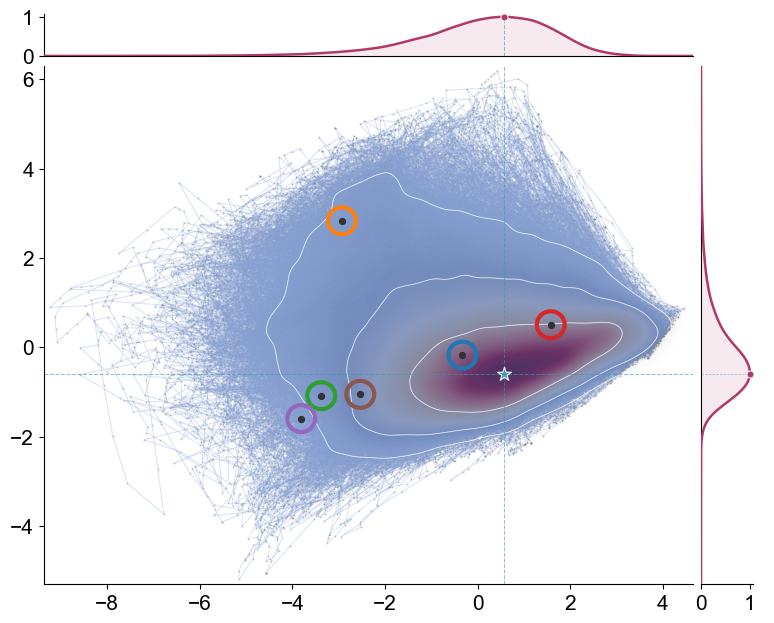

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle


# ============================================================
# 0. Basic settings
# ============================================================

out_path = 'figures/emotion_dynamic_space2_joint.svg'

traj_alpha = 0.30

plt.rcParams['font.size'] = 15


# ============================================================
# 1. Prepare density map
# ============================================================

# dens.shape = (len(ys), len(xs))
D = np.log1p(dens)

vmin = np.nanmin(D)
vmax = np.nanmax(D)


# Same density color scheme as before
colors = [
    'white',
    "#CCCBC9",
    '#FEE8C8',
    '#FDD49E',
    '#FDBB84',
    '#FC8D59',
    '#EF6548',
    '#D7301F',
    '#B30000',
    '#7F0000'
]

cmap = LinearSegmentedColormap.from_list(
    'white_OrRd',
    colors
)


# ============================================================
# 2. Find global density peak
#
# IMPORTANT:
# Everything below uses exactly the same grid cell.
# ============================================================

iy, ix = np.unravel_index(
    np.nanargmax(dens),
    dens.shape
)

x_peak = xs[ix]
y_peak = ys[iy]

peak_density = dens[iy, ix]

print(
    f"[Peak cell] iy={iy}, ix={ix}, "
    f"coord=({x_peak:.4f}, {y_peak:.4f})"
)

print(
    f"[Peak density] {peak_density:.6g}"
)


# ============================================================
# 3. Exact density cross-sections
#
# No interpolation:
#
# PC1 section:
#   fix PC2 = y_peak
#
# PC2 section:
#   fix PC1 = x_peak
# ============================================================

density_pc1 = dens[iy, :].copy()
density_pc2 = dens[:, ix].copy()


# Normalize both by exactly the same global density maximum

density_pc1_norm = (
    density_pc1 / peak_density
)

density_pc2_norm = (
    density_pc2 / peak_density
)


print(
    "PC1 profile maximum:",
    np.nanmax(density_pc1_norm),
    "at x =",
    xs[np.nanargmax(density_pc1_norm)]
)

print(
    "PC2 profile maximum:",
    np.nanmax(density_pc2_norm),
    "at y =",
    ys[np.nanargmax(density_pc2_norm)]
)


# These should both equal the global peak
assert np.isclose(
    density_pc1_norm[ix],
    1.0
)

assert np.isclose(
    density_pc2_norm[iy],
    1.0
)


# ============================================================
# 4. Correct image extent
#
# xs / ys are GRID CENTERS.
# imshow extent should describe GRID EDGES.
#
# This removes the half-cell alignment ambiguity.
# ============================================================

dx_grid = xs[1] - xs[0]
dy_grid = ys[1] - ys[0]

image_extent = (
    xs[0]  - dx_grid / 2,
    xs[-1] + dx_grid / 2,
    ys[0]  - dy_grid / 2,
    ys[-1] + dy_grid / 2
)


# ============================================================
# 5. Figure layout
#
#
#        PC1 density profile
#     ┌─────────────────────┐
#     │                     │
#     └─────────────────────┘
#
#     ┌─────────────────────┐ ┌───────┐  ┌───┐
#     │                     │ │       │  │   │
#     │     Main space      │ │ PC2   │  │ C │
#     │                     │ │ dens. │  │ B │
#     │                     │ │       │  │ A │
#     └─────────────────────┘ └───────┘  │ R │
#                                         └───┘
#
# ============================================================

fig = plt.figure(
    figsize=(9.3, 7.4),
    facecolor="white"
)


gs = fig.add_gridspec(
    nrows=2,
    ncols=3,

    # top profile relatively shallow
    height_ratios=[
        0.08,
        1.00
    ],

    # main / right profile / future colorbar
    width_ratios=[
        1.00,
        0.08,
        0.005
    ],

    hspace=0.035,
    wspace=0.035
)


# Main plot first
ax = fig.add_subplot(
    gs[1, 0]
)

# Profiles share coordinates with the main plot
ax_top = fig.add_subplot(
    gs[0, 0],
    sharex=ax
)

ax_right = fig.add_subplot(
    gs[1, 1],
    sharey=ax
)

# Reserved colorbar axis
ax_cbar = fig.add_subplot(
    gs[1, 2]
)


# Empty upper-right spaces
ax_empty_right = fig.add_subplot(
    gs[0, 1]
)

ax_empty_cbar = fig.add_subplot(
    gs[0, 2]
)

ax_empty_right.axis("off")
ax_empty_cbar.axis("off")


# ============================================================
# 6. Main 2D emotion-space plot
# ============================================================

ax.set_facecolor("white")


# ------------------------------------------------------------
# 6.1 Raw states
# ------------------------------------------------------------

idx = np.arange(
    len(X2)
)

ax.scatter(
    X2[idx, 0],
    X2[idx, 1],

    s=2.5,
    c="#333333",
    alpha=0.20,

    linewidths=0,
    zorder=0,
    rasterized=True
)

ax.scatter(
    X2[idx, 0],
    X2[idx, 1],

    s=1.0,
    c="#1A1A1A",
    alpha=0.40,

    linewidths=0,
    zorder=1,
    rasterized=True
)


# ------------------------------------------------------------
# 6.2 Movie trajectories
# ------------------------------------------------------------

for seg in traj_lines:

    ax.plot(
        seg[:, 0],
        seg[:, 1],

        lw=0.8,
        alpha=traj_alpha,

        color="#2E5CB8",
        zorder=1.2
    )


# ------------------------------------------------------------
# 6.3 Density map
# ------------------------------------------------------------
#
# IMPORTANT:
# extent uses pixel EDGES calculated above.
#
# ------------------------------------------------------------

im = ax.imshow(
    D,

    extent=image_extent,
    origin="lower",

    cmap=cmap,
    vmin=vmin,
    vmax=vmax,

    alpha=0.45,

    # Keep bilinear for the publication version.
    # Coordinates are still correctly aligned because extent
    # now uses pixel edges.
    interpolation="bilinear",

    aspect="auto",
    zorder=2
)


# ============================================================
# 7. HDR contours
# ============================================================

for t in thr:

    cs = ax.contour(
        XX,
        YY,
        dens,

        levels=[t],

        colors="white",
        linewidths=0.6,
        alpha=0.60,

        zorder=2.5
    )

    # compatibility with different matplotlib versions
    try:

        collections = cs.collections

        for c in collections:

            c.set_path_effects([
                pe.Stroke(
                    linewidth=0.4,
                    foreground="#FFFFFF88"
                ),
                pe.Normal()
            ])

    except AttributeError:

        pass


# ============================================================
# 8. Cross-section guide lines
# ============================================================

peak_color = '#3B9AB2'


# Vertical line:
# exact PC1 location of density maximum

ax.axvline(
    x_peak,

    color=peak_color,
    lw=0.75,
    ls="--",
    alpha=0.60,

    zorder=3
)


# Horizontal line:
# exact PC2 location of density maximum

ax.axhline(
    y_peak,

    color=peak_color,
    lw=0.75,
    ls="--",
    alpha=0.60,

    zorder=3
)


# ============================================================
# 9. Emotion centers
# ============================================================

center_mass = X2.mean(
    axis=0
)


for k, (cx, cy) in enumerate(C2):

    ring = Circle(
        (cx, cy),

        radius=(
            0.22
            * max(dx, dy)
            / 10
        ),

        facecolor="none",
        edgecolor=EMO_COLORS_WHITE_BG[k],

        linewidth=3.0,
        zorder=4
    )

    ax.add_patch(
        ring
    )

    ax.scatter(
        [cx],
        [cy],

        s=18,

        color="#333333",

        zorder=5
    )


# ============================================================
# 10. Global density peak
# ============================================================

ax.scatter(
    [x_peak],
    [y_peak],

    s=108,
    marker="*",

    color=peak_color,

    edgecolor="#FFFFFFDD",
    linewidth=0.9,

    zorder=6
)


# ============================================================
# 11. Main axis formatting
# ============================================================

ax.set_xlim(
    xmin,
    xmax
)

ax.set_ylim(
    ymin,
    ymax
)


# Leave labels empty.
# You can add large PC1/PC2 labels later with fig.text().

ax.set_xlabel("")
ax.set_ylabel("")


ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)


# ============================================================
# 12. Top profile: PC1 density cross-section
# ============================================================

profile_color = "#B0396A"


ax_top.plot(
    xs,
    density_pc1_norm,

    color=profile_color,
    lw=1.8,

    zorder=3
)


ax_top.fill_between(
    xs,

    0,
    density_pc1_norm,

    color=profile_color,
    alpha=0.10,

    linewidth=0,
    zorder=1
)


# Exact global peak coordinate

ax_top.axvline(
    x_peak,

    color=peak_color,
    lw=0.75,
    ls="--",
    alpha=0.60,

    zorder=2
)


# Actual grid peak

ax_top.scatter(
    [xs[ix]],
    [density_pc1_norm[ix]],

    s=26,

    color=profile_color,

    edgecolor="white",
    linewidth=0.7,

    zorder=4
)


# ------------------------------------------------------------
# Top profile formatting
# ------------------------------------------------------------

ax_top.set_xlim(
    xmin,
    xmax
)

ax_top.set_ylim(
    0,
    1.06
)


# x ticks belong to the main panel
ax_top.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)


ax_top.set_yticks(
    [0, 1]
)


ax_top.set_ylabel(
    ""
)


ax_top.spines["top"].set_visible(
    False
)

ax_top.spines["right"].set_visible(
    False
)

ax_top.spines["bottom"].set_visible(
    True
)


# Optional small title.
# Remove this if panel already gets external annotation.

# ax_top.text(
#     0.50,
#     0.97,

#     "PC1 cross-section",

#     transform=ax_top.transAxes,

#     ha="center",
#     va="top",

#     fontsize=11
# )


# ============================================================
# 13. Right profile: PC2 density cross-section
# ============================================================

ax_right.plot(
    density_pc2_norm,
    ys,

    color=profile_color,
    lw=1.8,

    zorder=3
)


ax_right.fill_betweenx(
    ys,

    0,
    density_pc2_norm,

    color=profile_color,
    alpha=0.10,

    linewidth=0,
    zorder=1
)


# Exact global peak PC2 coordinate

ax_right.axhline(
    y_peak,

    color=peak_color,
    lw=0.5,
    ls="--",
    alpha=0.60,

    zorder=2
)


# Actual grid peak

ax_right.scatter(
    [density_pc2_norm[iy]],
    [ys[iy]],

    s=26,

    color=profile_color,

    edgecolor="white",
    linewidth=0.7,

    zorder=4
)


# ------------------------------------------------------------
# Right profile formatting
# ------------------------------------------------------------

ax_right.set_ylim(
    ymin,
    ymax
)

ax_right.set_xlim(
    0,
    1.06
)


# y coordinates already shown on main axis
ax_right.tick_params(
    axis="y",
    left=False,
    labelleft=False
)


ax_right.set_xticks(
    [0, 1]
)


ax_right.set_xlabel(
    ""
)


ax_right.spines["top"].set_visible(
    False
)

ax_right.spines["right"].set_visible(
    False
)

ax_right.spines["left"].set_visible(
    True
)


# ax_right.text(
#     0.50,
#     1.02,

#     "PC2\ncross-section",

#     transform=ax_right.transAxes,

#     ha="center",
#     va="bottom",

#     fontsize=11,
#     linespacing=0.9
# )


# ============================================================
# 14. Reserve colorbar space
# ============================================================
#
# For now hide it.
#
# Later you can replace this with:
#
# cbar = fig.colorbar(im, cax=ax_cbar)
# cbar.set_label("Density")
#
# ============================================================

ax_cbar.axis(
    "off"
)


# ============================================================
# 15. Optional final PC labels
#
# You said you will add these later.
# Uncomment when needed.
# ============================================================

# fig.text(
#     0.42,
#     0.015,
#     "PC1 (Polarity)",
#     ha="center",
#     va="bottom",
#     fontsize=16
# )

# fig.text(
#     0.015,
#     0.40,
#     "PC2 (Complexity)",
#     ha="left",
#     va="center",
#     rotation=90,
#     fontsize=16
# )


# ============================================================
# 16. Save
# ============================================================

plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
from matplotlib.patches import Circle
from matplotlib.path import Path
import numpy as np


iy, ix = np.unravel_index(np.argmax(dens), dens.shape)  
x_peak, y_peak = XX[iy, ix], YY[iy, ix]                 
print(f"[Peak cell] iy={iy}, ix={ix}, coord=({x_peak:.4f}, {y_peak:.4f})")

# Use all points within the peak grid
x_vals = np.unique(XX[0, :])
y_vals = np.unique(YY[:, 0])
dx = np.mean(np.diff(x_vals))
dy = np.mean(np.diff(y_vals))

x_min_cell = x_peak - dx / 2
x_max_cell = x_peak + dx / 2
y_min_cell = y_peak - dy / 2
y_max_cell = y_peak + dy / 2

pts = np.column_stack([X2[:, 0], X2[:, 1]])  # (T, 2)
mask_peak_cell = (
    (pts[:, 0] >= x_min_cell) & (pts[:, 0] < x_max_cell) &
    (pts[:, 1] >= y_min_cell) & (pts[:, 1] < y_max_cell)
)
n_cell = int(mask_peak_cell.sum())
print(f"[Peak cell samples] n_cell={n_cell}")

# if n_cell > 0:
#     vec_peak = scores_all[mask_peak_cell].astype(float)  # (n_cell, 6)
#     mean_peak = vec_peak.mean(axis=0)                    # (6,)
#     prop_peak = mean_peak / (mean_peak.sum() + 1e-12)
# else:
d2 = (X2[:, 0] - x_peak)**2 + (X2[:, 1] - y_peak)**2
idx0 = int(np.argmin(d2))
print(f"[Nearest sample index to peak] idx0={idx0}")
vec_peak = scores_all[idx0].astype(float)            # (6,)
prop_peak = vec_peak / (vec_peak.sum() + 1e-12)

print("[Peak point emotion proportions] ", prop_peak)

[Peak cell] iy=162, ix=283, coord=(0.5680, -0.5917)
[Peak cell samples] n_cell=52
[Nearest sample index to peak] idx0=287314
[Peak point emotion proportions]  [0.33475177 0.26808511 0.05673759 0.17730496 0.09787234 0.06524823]


In [20]:
levels=(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0)
thr2 = _hdr_thresholds(dens, levels=levels, cell_area=cell_area)
prop_region_thrs = []
for i in range(len(levels)):
    CS_tmp = ax.contour(XX, YY, dens, levels=[thr2[i]], colors='none')
    paths = CS_tmp.collections[0].get_paths()

    path_peak = None
    for pth in paths:
        if pth.contains_point((x_peak, y_peak)):
            path_peak = pth
            break
    if path_peak is None and len(paths) > 0:
        path_peak = max(paths, key=lambda p: len(p.vertices))

    if path_peak is not None:
        pts = np.column_stack([X2[:, 0], X2[:, 1]])                 # (T,2)
        mask_in = np.array([path_peak.contains_point(tuple(pt)) for pt in pts])
        n_in = int(mask_in.sum())
        print(f"[Peak-region mask] n_in={n_in}")
        if n_in > 0:
            vec_region = scores_all[mask_in].astype(float)                  # (n_in,6)
            mean_region = vec_region.mean(axis=0)
            prop_region = mean_region / (mean_region.sum() + 1e-12)
            print("[Peak-region emotion proportions] ", np.round(prop_region, 3))

            ax.scatter(X2[mask_in, 0], X2[mask_in, 1], s=3,
                    facecolor="#FFFFFF", edgecolor="none", alpha=0.15, zorder=5, rasterized=True)
            
            prop_region_thrs.append(prop_region)
    else:
        print("[Warn] No closed contour found at this level; consider lowering `level` (e.g., 0.85 * max).")

C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\2324914311.py:6: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = CS_tmp.collections[0].get_paths()


[Peak-region mask] n_in=90724
[Peak-region emotion proportions]  [0.242 0.239 0.13  0.176 0.123 0.089]
[Peak-region mask] n_in=322877
[Peak-region emotion proportions]  [0.309 0.266 0.099 0.145 0.104 0.077]
[Peak-region mask] n_in=288035
[Peak-region emotion proportions]  [0.318 0.272 0.088 0.144 0.103 0.075]
[Peak-region mask] n_in=253616
[Peak-region emotion proportions]  [0.325 0.277 0.081 0.142 0.102 0.073]
[Peak-region mask] n_in=218989
[Peak-region emotion proportions]  [0.33  0.28  0.076 0.141 0.101 0.072]
[Peak-region mask] n_in=183690
[Peak-region emotion proportions]  [0.334 0.283 0.073 0.14  0.101 0.07 ]
[Peak-region mask] n_in=147862
[Peak-region emotion proportions]  [0.337 0.284 0.07  0.139 0.1   0.068]
[Peak-region mask] n_in=111590
[Peak-region emotion proportions]  [0.338 0.285 0.068 0.14  0.101 0.068]
[Peak-region mask] n_in=74488
[Peak-region emotion proportions]  [0.338 0.286 0.067 0.141 0.101 0.067]
[Peak-region mask] n_in=37024
[Peak-region emotion proportions]  [

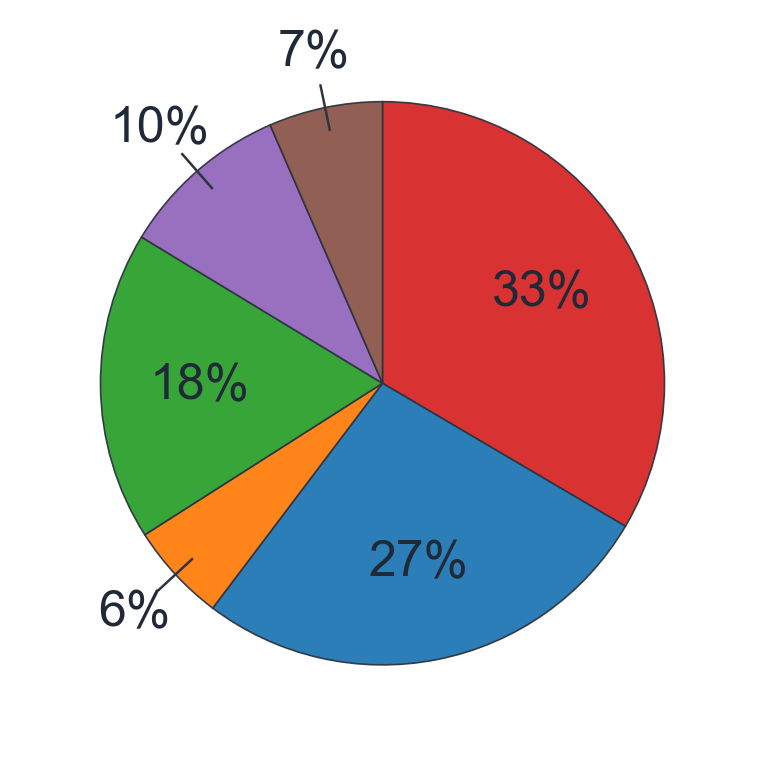

In [21]:
import numpy as np
import matplotlib.pyplot as plt

emos   = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

def plot_single_pie(props,
                    emos=emos, colors=colors,
                    annotate=True,
                    outside_thresh=0.10,  # <10% 的外置标签
                    savepath=None, figsize=(2.8, 2.8), dpi=300):
    p = np.asarray(props, float)
    p = p / (p.sum() + 1e-12)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.axis("equal")

    wedges, _ = ax.pie(
        p, labels=None, colors=colors,
        startangle=90, counterclock=False,
        wedgeprops=dict(edgecolor="#2E3440", linewidth=0.4, alpha=0.95)
    )

    if annotate:
        for w, val in zip(wedges, p):
            if val <= 0:
                continue
            theta = np.deg2rad((w.theta1 + w.theta2) / 2.0) 
            x, y = np.cos(theta), np.sin(theta)
            label = f"{val*100:.0f}%"

            if val < outside_thresh: 
                r1, r2, r_txt = 0.92, 1.08, 1.2
                ax.plot([r1*x, r2*x], [r1*y, r2*y], color="#2E3440", lw=0.6)
                ax.text(r_txt*x, r_txt*y, label,
                        ha="center", va="center", fontsize=12, color="#1F2937")
            else:                    
                ax.text(0.65*x, 0.65*y, label,
                        ha="center", va="center", fontsize=12, color="#1F2937")

    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, ax

props = prop_peak 
fig, ax = plot_single_pie(props,
                          savepath="figures/peak_pie.svg")
plt.show()


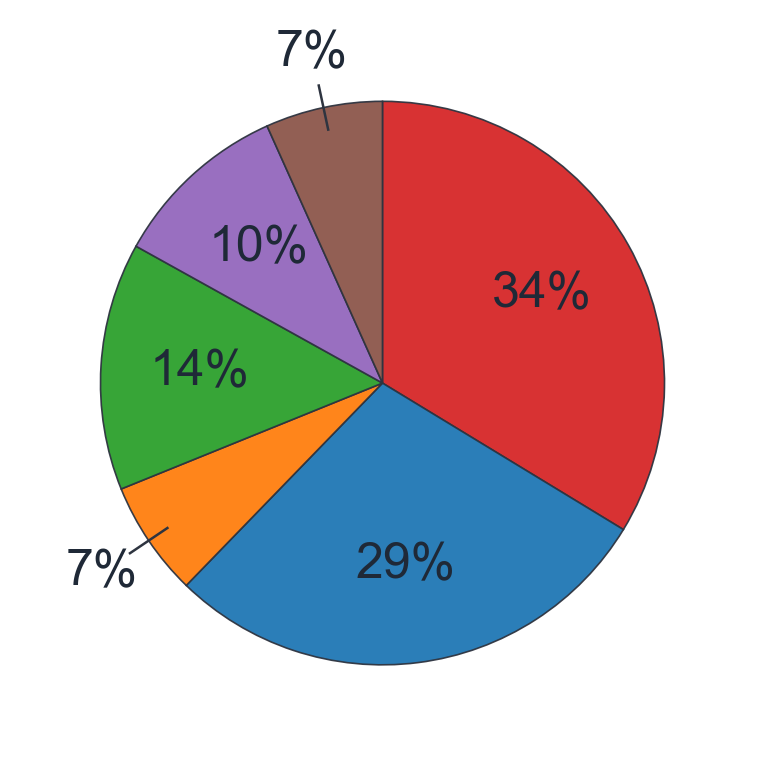

In [22]:
fig, ax = plot_single_pie(prop_region_thrs[-1],
                          savepath="figures/peak_pie_all.svg")
plt.show()

In [23]:
movie_names_eng = [
    "Batman Dark Knight",
    "Be Somebody",
    "Forrest Gump",
    "Big World Gashapon",
    "Godzilla",
    "Green Book",
    "Harry Potter and the Goblet of Fire",
    "Heidi",
    "Kung Fu",
    "Let the Bullets Fly",
    "The Legend of Luo Xiaohei",
    "The Bad Guys",
    "The Shawshank Redemption",
    "The Wandering Earth II",
    "Weathering With You",
    "White Snake",
    "World War Z",
    "Yang Jian",
    "Suzume",  # 铃芽之旅
    "Johnny Keep Walking!",  # 年会不能停!
    "The Lord of the Rings: The Fellowship of the Ring",  # 指环王1
    "The SpongeBob SquarePants Movie",  # 海绵宝宝历险记
    "Our Fathers",  # 我们的父辈
    "Detective Conan: The Phantom of Baker Street",  # 名侦探柯南
    "Love Letter",  # 情书
    "Harry Potter and the Order of the Phoenix",
    "Detective Conan: The Bride of Halloween",
    "White Snake 2: The Tribulation of Green Snake",
    "New Gods: Nezha Reborn",
    "The Truman Show",  # 楚门的世界
    "Transformers",
    "Flipped",  # 怦然心动
    "The Pig, the Snake and the Pigeon",  # 周处除三害
    "Date A Live Movie: Mayuri Judgment",
    "Rascal Does Not Dream of a Dreaming Girl",
    "Violet Evergarden: The Movie",
    "Journey to the West",  # 宇宙探索编辑部
    "Sword Art Online: Ordinal Scale",  # 刀剑神域
    "Overlord: The Dark Hero",
    "Rurouni Kenshin",  # 浪客剑心
    "A Silent Voice",  # 声之形
    "Harry Potter and the Half-Blood Prince",
    "Harry Potter and the Chamber of Secrets",
    "Still Miss You",  # 还是觉得你最好
    "Ready Player One",  # 头号玩家
    "Edge of Tomorrow",  # 明日边缘
    "Transformers: Revenge of the Fallen",
    "Fate/stay night: Heaven's Feel I. presage flower",
    "Fantastic Beasts and Where to Find Them",
    "Harry Potter and the Sorcerer's Stone",
    "Promare",  # 普罗米亚
    "Fireworks",  # 烟花
    "Goodbye Mr. Loser",  # 夏洛特烦恼
    "Tamako Love Story",  # 玉子爱情故事
    "Leap",  # 夺冠
    "A Little Thing Called Love",  # 初恋这件小事
    "The Legend of Sealed Book",  # 天书奇谭
    "The SpongeBob Movie: Sponge Out of Water",  # 海绵宝宝水兵陆战队
    "The Garden of Words",  # 言叶之庭
    "Kowloon Walled City",  # 九龙城寨
    "The Silence of the Lambs",
    "Inception",  # 盗梦空间
    "Interstellar",
    "Deep Sea",  # 深海
    "Jiang Ziya",  # 姜子牙
    "Harry Potter and the Deathly Hallows Part 2",
    "CJ7",  # 长江七号
    "Lost on Journey",  # 人在囧途
    "Only Fools Rush In",  # 四海
    "Five Hundred Miles",  # 交换人生
    "The Godfather",
    "Harry Potter and the Prisoner of Azkaban",
    "Minions",  # 小黄人大眼萌
    "Violet Evergarden: Eternity and the Auto Memories Doll",
    "One Second",  # 一秒钟
    "Sword Art Online Progressive: Aria of a Starless Night",
    "Catch Me If You Can",  # 猫鼠游戏
    "Wolf Warrior",  # 战狼
    "Brotherhood of Blades",  # 绣春刀
    "Hidden Blade",  # 无名
    "Endless Journey",  # 三大队
    "Pegasus 2",  # 飞驰人生2
    "Evangelion: 2.22 You Can (Not) Advance",
    "Evangelion: 3.33 You Can (Not) Redo",
    "Evangelion: 1.11 You Are (Not) Alone",
    "Evangelion: Death and Rebirth",
    "Crazy Racer",  # 疯狂的赛车
    "My Little Pony Equestria Girls: Friendship Games",  # 彩虹小马
    "My Own Swordsman",  # 武林外传
    "Words Bubble Up Like Soda Pop",  # 言语如苏打般涌现
    "No Time to Die",  # 007
    "Overlord: The Undead King",
    "5 Centimeters Per Second",  # 秒速5厘米
    "Win the Kids",  # 抓娃娃
    "The Founding of a Republic",  # 建国大业
    "Ip Man",  # 叶问
    "The King's Avatar: For the Glory",  # 全职高手
    "Shin Ultraman",  # 新·奥特曼
    "Pleasant Goat and Big Big Wolf: Dunk for Future",  # 喜羊羊
    "One Piece Film: Red",  # 航海王
    "Johnny English",  # 憨豆特工
    "Pacific Rim"  # 环太平洋
]

In [24]:
sel_movies = ['Forrest Gump', 'World War Z', 'Godzilla', 'The Bad Guys', 'The Godfather', 'White Snake']
use_inds = []
for i in range(6):
    use_inds.append(movie_names_eng.index(sel_movies[i]))
print(use_inds)

[2, 16, 4, 11, 70, 15]


Forrest Gump
anchors per emotion: [1462  181  392   60    2   11]


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\1452983038.py:80: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cs.collections:


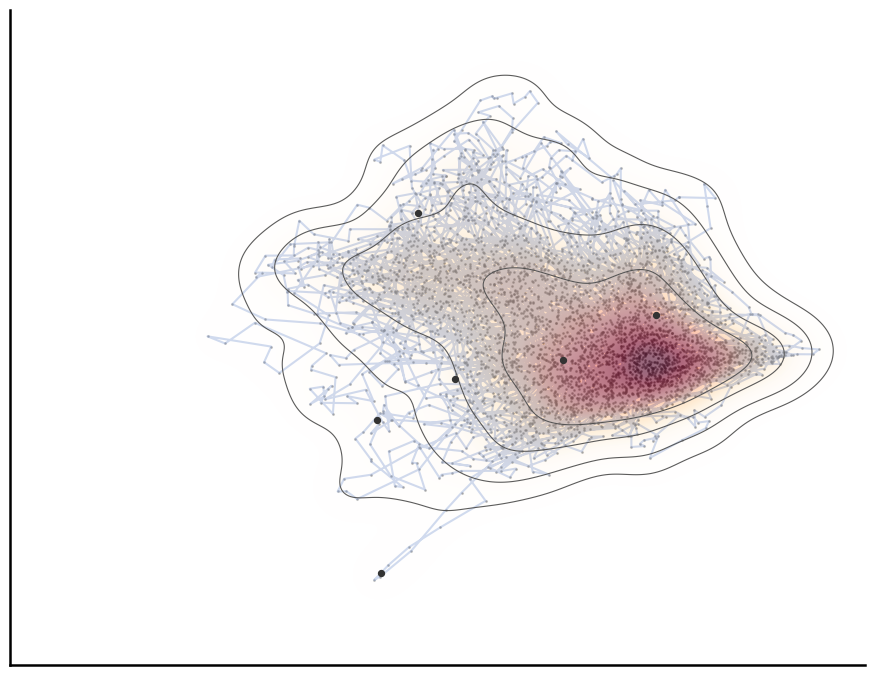

World War Z
anchors per emotion: [590 924  17 216   4  93]


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\1452983038.py:80: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cs.collections:


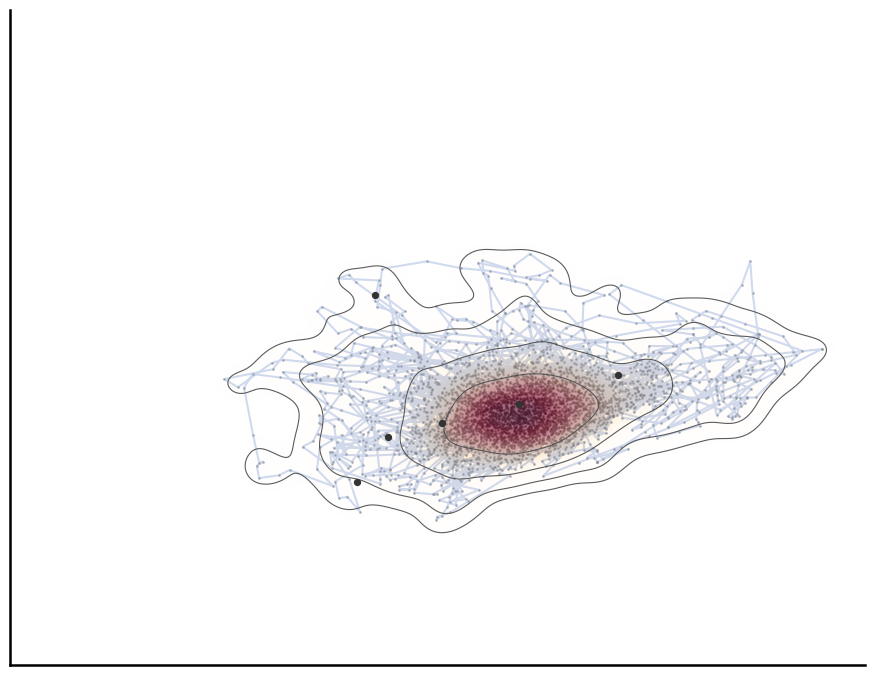

Godzilla
anchors per emotion: [709 898  18 352   0   0]
Removed 2 invalid emotion centers


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\478465052.py:85: RuntimeWarning: Mean of empty slice.
  centers[k] = Xk2.mean(axis=0)
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\478465052.py:86: RuntimeWarning: Degrees of freedom <= 0 for slice
  C = np.cov(Xk2, rowvar=False)
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encoun

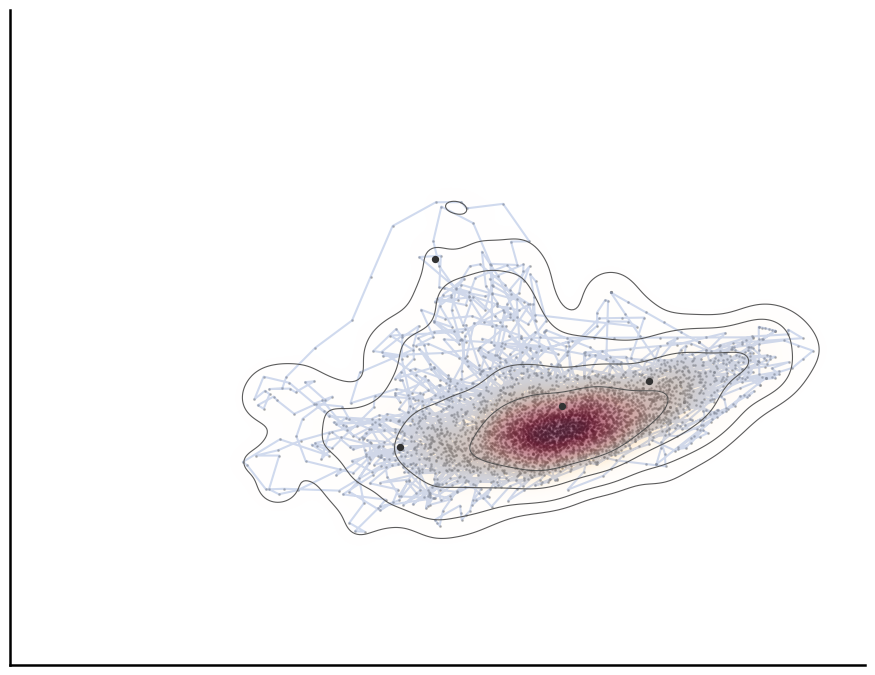

The Bad Guys
anchors per emotion: [1287  179   14   22    0    0]
Removed 2 invalid emotion centers


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\478465052.py:85: RuntimeWarning: Mean of empty slice.
  centers[k] = Xk2.mean(axis=0)
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\478465052.py:86: RuntimeWarning: Degrees of freedom <= 0 for slice
  C = np.cov(Xk2, rowvar=False)
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Windows\anaconda3\envs\cl_sster_env\envs\llm_openai\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encoun

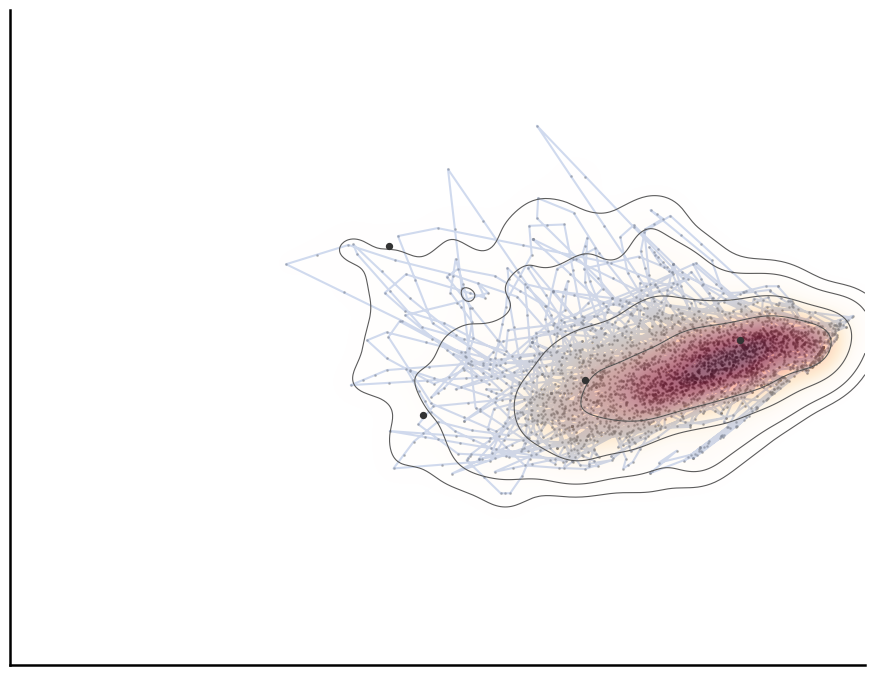

The Godfather
anchors per emotion: [1425  556  172  461    8   33]


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\1452983038.py:80: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cs.collections:


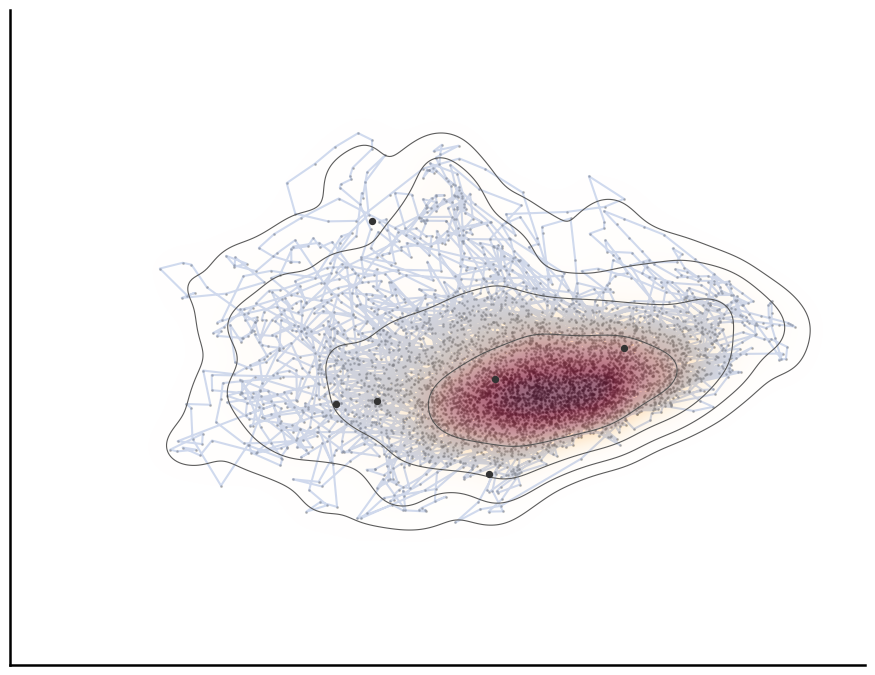

White Snake
anchors per emotion: [1145  157  128   87    3    7]


C:\Users\Windows\AppData\Local\Temp\ipykernel_31792\1452983038.py:80: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cs.collections:


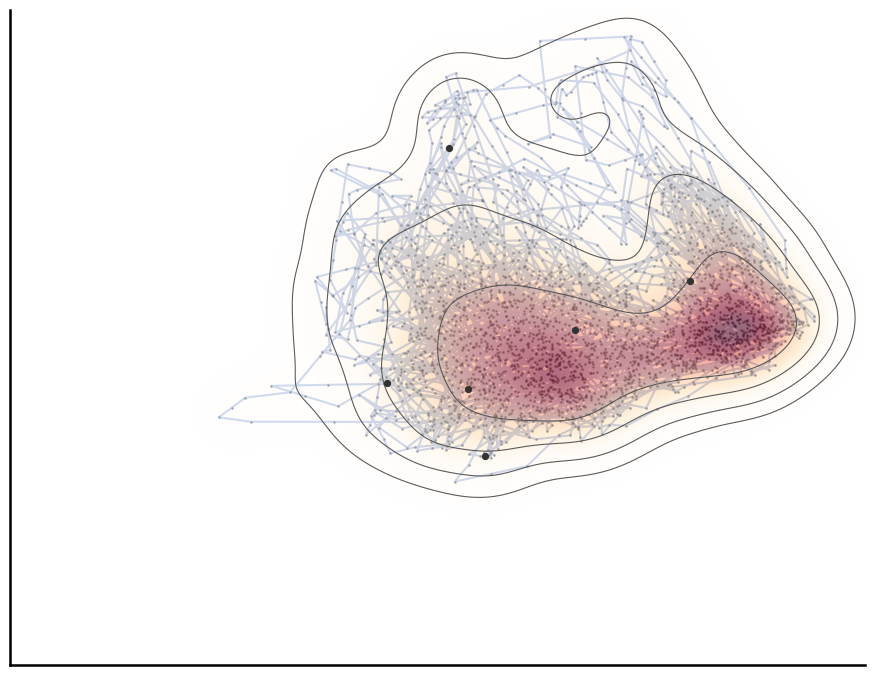

In [25]:
for i in use_inds:
    print(movie_names_eng[i])
    scores_now = scores_all[n_samples_cum[i]: n_samples_cum[i+1]]
    centers6, covs6, counts = fit_six_emotion_anchors(
        scores_now,        # (N, 6)
        topk_frac=0.50
        )
    print("anchors per emotion:", counts)
    
    nan_mask = np.isnan(centers6).any(axis=1)
    if nan_mask.any():
        print(f"Warning: Found NaN values in centers6 for emotion indices: {np.where(nan_mask)[0]}")
        valid_indices = ~nan_mask
        centers6 = centers6[valid_indices]
        covs6 = covs6[valid_indices]
        counts = counts[valid_indices]
        print(f"Removed {nan_mask.sum()} invalid emotion centers")

    random_state = 0
    grid_res=400
    bandwidth=None
    bandwidth_scale=1.0
    glow_sigma=6.0
    levels=(0.5, 0.8, 0.95, 0.99)
        
    rng = np.random.default_rng(random_state)

    # 1) PCA(2) on pooled data
    # pca = PCA(n_components=2, svd_solver="full", random_state=random_state)
    X2 = pca.transform(scores_now)
    C2 = pca.transform(centers6)  

    # 3) KDE on a shared grid
    pad = 0.06
    xs = np.linspace(xmin, xmax, grid_res)
    ys = np.linspace(ymin, ymax, grid_res)
    cell_area = (xs[1]-xs[0]) * (ys[1]-ys[0])

    if bandwidth is None:
        bandwidth = _scott_bandwidth(X2) * float(bandwidth_scale)

    XX, YY, dens = _kde_on_grid(X2, xs, ys, bandwidth)
    dens_blur = gaussian_filter(dens, sigma=glow_sigma)
    thr = _hdr_thresholds(dens, levels=levels, cell_area=cell_area)

    # out_path_jpg='figures/emotion_dynamic_space.svg'
    traj_alpha=0.4

    fig = plt.figure(figsize=(9, 7), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    D = np.log1p(dens)          # log

    vmin = np.min(D)
    vmax = np.max(D)

    colors = ['white', '#FFF7EC', '#FEE8C8', '#FDD49E', '#FDBB84', '#FC8D59', '#EF6548', '#D7301F', '#B30000', '#7F0000']
    cmap = LinearSegmentedColormap.from_list('white_OrRd', colors)

    idx = np.arange(len(X2))
    ax.scatter(X2[idx,0], X2[idx,1],
            s=5, c="#333333", alpha=0.3,
            linewidths=0, zorder=0, rasterized=True)

    ax.scatter(X2[idx,0], X2[idx,1],
            s=2, c="#1A1A1A", alpha=0.6,
            linewidths=0, zorder=1, rasterized=True)

    ax.plot(X2[:,0], X2[:,1], lw=1.5, alpha=traj_alpha, color="#2E5CB8")
        
    im = ax.imshow(
        D, extent=(xmin, xmax, ymin, ymax), origin="lower",
        cmap=cmap, vmin=vmin, vmax=vmax,
        alpha=0.45, interpolation="bilinear", aspect="auto", zorder=2
    )

    for t in thr:
        cs = ax.contour(XX, YY, dens, levels=[t], colors="#333333", linewidths=0.8, alpha=0.8)
        for c in cs.collections:
            c.set_path_effects([pe.Stroke(linewidth=0.6, foreground="#FFFFFF88"), pe.Normal()])

    center_mass = X2.mean(axis=0)
    for k, (cx, cy) in enumerate(C2):
        if np.isnan(cx) or np.isnan(cy):
            print(f"Skipping emotion center {k} due to NaN values")
            continue
            
        ring = Circle((cx, cy), radius=0.22*max(dx,dy)/10,
                        facecolor='none', edgecolor=EMO_COLORS_WHITE_BG[k], linewidth=3.0, zorder=3)
        ax.add_patch(ring)
        ax.scatter([cx], [cy], s=18, color="#333333", zorder=4)
        v = np.array([cx, cy]) - center_mass
        v = v / (np.linalg.norm(v) + 1e-9)
        lx, ly = cx + 0.02*dx*v[0], cy + 0.04*dy*v[1]

    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_xticks([]); ax.set_yticks([])
    # ax.set_aspect('equal')
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('figures/dynamic_space_%s.svg' % scores_key[i], bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
def find_emotion_center_use_inds(scores_all, topk_frac=0.50, eps=1e-6):
    X = np.asarray(scores_all, float)
    N, D = X.shape
    assert D == 6

    idx_all = {}

    for k in range(6):
        mask = (X.argmax(axis=1) == k)
        orig_idx = np.where(mask)[0]  
        Xk = X[orig_idx]

        m = len(Xk)
        if m == 0:
            idx_all[k] = np.array([], dtype=int)
            continue

        kk = max(1, int(topk_frac * m))
        order = np.argsort(Xk[:, k])[::-1][:kk]  

        idx_all[k] = orig_idx[order]

    return idx_all

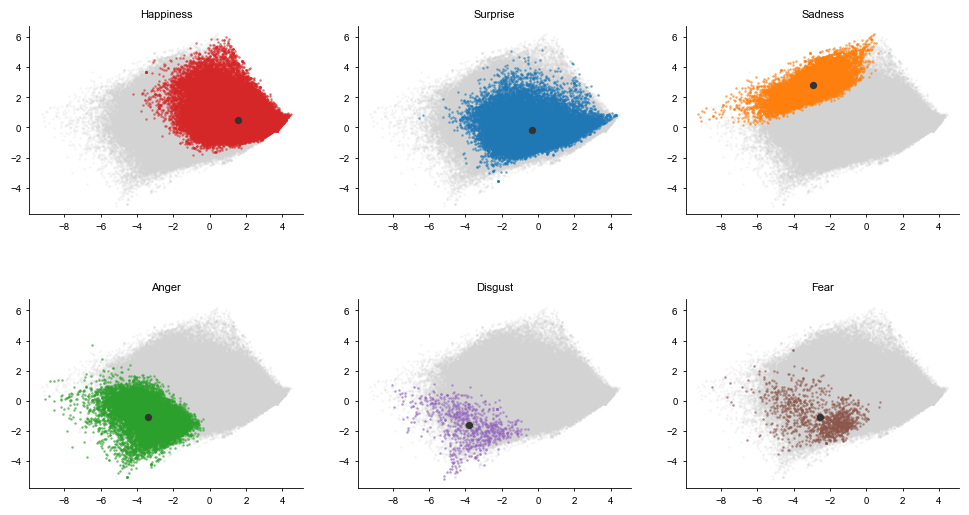

In [50]:
EMO_COLORS = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 6),
    gridspec_kw={'hspace': 0.45}
)

all_inds = np.arange(X2.shape[0])
use_inds_dict = find_emotion_center_use_inds(scores_all)

for i, ax in enumerate(axes.flat):
    use_inds = use_inds_dict[i]

    ax.scatter(
        X2[all_inds, 0],
        X2[all_inds, 1],
        s=3,
        color="lightgray",
        alpha=0.25,
        linewidths=0,
        zorder=1
    )

    ax.scatter(
        X2[use_inds, 0],
        X2[use_inds, 1],
        s=3,
        color=EMO_COLORS[i],
        alpha=0.65,
        linewidths=0,
        zorder=2
    )

    # ax.set_xlim(xmin, xmax)
    # ax.set_ylim(ymin, ymax)
    ax.set_title(EMO_NAMES[i])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 当前情绪点的中心
    cx = np.mean(X2[use_inds, 0])
    cy = np.mean(X2[use_inds, 1])

    ax.scatter(
        [cx], [cy],
        s=18,
        color="#333333",
        zorder=4
    )
plt.savefig('figures/emo_points.jpg', dpi=300, bbox_inches='tight')
plt.show()